# UAV LiDAR → DTM / DSM / CHM Workflow
**Ground classification via CSF (Zhang et al. 2016) and TIN interpolation**
**Chunked & parallelized for large point clouds**

## Overview

This workflow processes a UAV LiDAR `.las` file through the following steps:

1.  Load and inspect the point cloud
2.  Classify ground points using the **Cloth Simulation Filter (CSF)**
3.  Generate a **Digital Terrain Model (DTM)** via TIN interpolation
4.  Height-normalize the point cloud
5.  Generate a **Digital Surface Model (DSM)** from first returns
6.  Subtract to produce a **Canopy Height Model (CHM)**
7.  Clip to the boundary of the Area of Interest
8.  Summarize canopy height statistics

---

## Setup

Install required packages if you haven't already:

In [ ]:
## install.packages(c("terra", "RCSF", "sf", "lidR", "future"))

In [10]:
library(terra)
library(sf)
library(RCSF)
library(lidR)
library(future)

# Reserve one core for OS tasks (file I/O, memory management, etc.)
plan(multisession, workers = min(parallel::detectCores() - 1, 60))

# out_dir: where final output .tif files are saved (DTM, DSM, CHM)
out_dir <- readline(prompt = "Enter output folder path: ")
cat("Saving outputs to:", out_dir, "\n")
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# scratch_dir: where intermediate tiled .laz files are written during processing
# Use a simple path with no spaces, ideally on the same drive as your .las file
scratch_dir <- readline(prompt = "Enter scratch folder path (e.g. E:/LiDAR_scratch): ")
cat("Scratch directory:", scratch_dir, "\n")
dir.create(file.path(scratch_dir, "classified"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(scratch_dir, "normalized"), recursive = TRUE, showWarnings = FALSE)

Saving outputs to: C:\Users\kdavis99\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\GitHub_Repository\Rasters 
Scratch directory: E:/LiDAR_scratch 


---

## 1. Load the Point Cloud

`file.choose()` opens a native OS file browser so you can navigate to
your `.las` or `.laz` file interactively, rather than hardcoding a path.

The file is loaded as a **catalog** rather than a single LAS object.
This tells lidR to tile and parallelize all subsequent steps rather than
processing the full file in one single-threaded pass.

> **Note:** the dialog may open behind your VS Code window — check your taskbar.

In [11]:
message("Please select your LAS or LAZ file in the file browser.")

las_path <- file.choose()
cat("Selected file:", las_path, "\n")

# Load as a catalog so lidR can tile and parallelize all subsequent steps
ctg <- readLAScatalog(las_path,
                      select = "xyzrci",           # load x, y, z, return number, classification, intensity
                      filter = "-drop_z_below 0")  # drop obviously bad points below ground

# Quick check: point count, CRS, tile layout
print(ctg)

Please select your LAS or LAZ file in the file browser.



Selected file: E:\GSL Projects\Projects - In Progress\Bartleson Ranch\2026-08-29 Bartleson 4A 4B\exports\2026-08-29-Bartleson-4A4B.las 
class       : LAScatalog (v1.2 format 3)
extent      : 1768539, 1769227, 678389.8, 678997.6 (xmin, xmax, ymin, ymax)
coord. ref. : NAD83(2011) / California zone 5 
area        : 418540.4 m²
points      : 446.96 million points
density     : 1067.9 points/m²
density     : 1017.4 pulses/m²
num. files  : 1 


---

## 2. Ground Classification with CSF

CSF (Zhang et al. 2016) simulates a cloth dropped over an **inverted**
point cloud. The cloth drapes down under gravity and the points that end
up close to the cloth are labelled as ground.

Key parameters:

| Parameter | What it controls |
|---|---|
| `sloop_smooth` | Post-processing step to recover ground points on steep slopes. `FALSE` for flat terrain. |
| `class_threshold` | Max distance (m) a point can be from the cloth to still be called ground |
| `cloth_resolution` | Grid cell size of the simulated cloth (m) — smaller = finer detail, slower |
| `rigidness` | How much the cloth resists bending: 1 = flexible (hilly), 2 = medium, 3 = rigid (flat) |
| `iterations` | More iterations = cloth drapes more accurately, but slower |
| `time_step` | Internal physics timestep — leave at default 0.65 |

Chunk 2 of 4 (25%): state Ø
Chunk 1 of 4 (50%): state <U+2713>
Chunk 4 of 4 (75%): state <U+2713>
Chunk 3 of 4 (100%): state <U+2713>
Ground classification complete


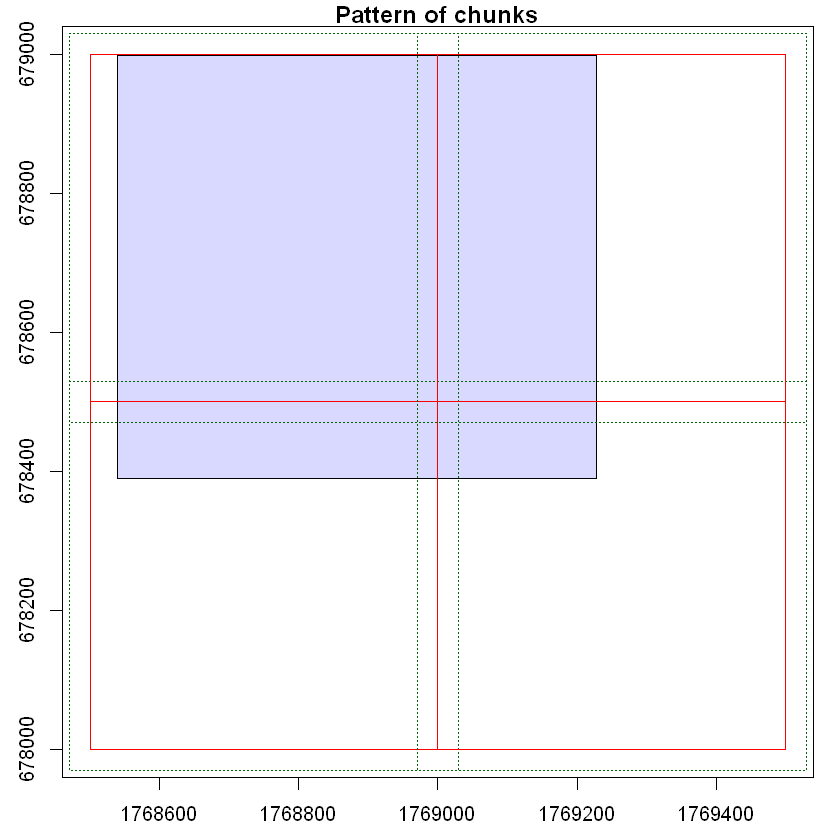

In [3]:
# Each tile is 500 x 500 meters of the lidar point cloud — reduce to 250 if you run into memory pressure
opt_chunk_size(ctg)      <- 500

# 30 m overlap between tiles so the cloth has enough neighboring points
# at tile edges to classify correctly — prevents seams in the output
opt_chunk_buffer(ctg)    <- 30

# Write each classified tile to scratch_dir (no spaces in path, same drive as .las)
opt_output_files(ctg)    <- file.path(scratch_dir, "classified/tile_{XLEFT}_{YBOTTOM}")

# Compress output to .laz to save disk space (lossless, lidR reads it identically to .las)
opt_laz_compression(ctg) <- TRUE

ctg_classified <- classify_ground(
  ctg,
  algorithm = csf(
    sloop_smooth     = FALSE,  # FALSE for flat/gentle terrain
    class_threshold  = 0.5,    # points within 0.5 m of cloth are classified as ground
    cloth_resolution = 0.5,    # cloth cell size in metres
    rigidness        = 2,      # 2 = medium; use 3 for very flat/open terrain
    iterations       = 500,
    time_step        = 0.65
  )
)

cat("Ground classification complete\n")

---

## 3. DTM via Adaptive Triangulation

`rasterize_terrain()` converts the ground-classified points into a
continuous raster elevation surface — the DTM.

**How TIN interpolation works:**

1.  Takes all ground-classified points
2.  Connects them into a mesh of non-overlapping triangles (Delaunay triangulation)
3.  Triangle sizes naturally adapt to local point density — smaller where points are dense, larger where they are sparse
4.  For each output raster cell, elevation is interpolated from the plane defined by the three vertices of whichever triangle contains that cell centre

This approach honours every ground point exactly without smoothing,
making it the most accurate method for DTM generation from lidar (Mishra & Singh 2026).

> **Note:** TIN is memory intensive. Workers are reduced to 2 here so only
> 2 tiles process simultaneously, preventing memory exhaustion on dense clouds.

Chunk 1 of 3 (33.3%): state <U+2713>
Chunk 3 of 3 (66.7%): state <U+2713>
Chunk 2 of 3 (100%): state <U+2713>
DTM written to bart_chunk_dtm_0.1m.tif


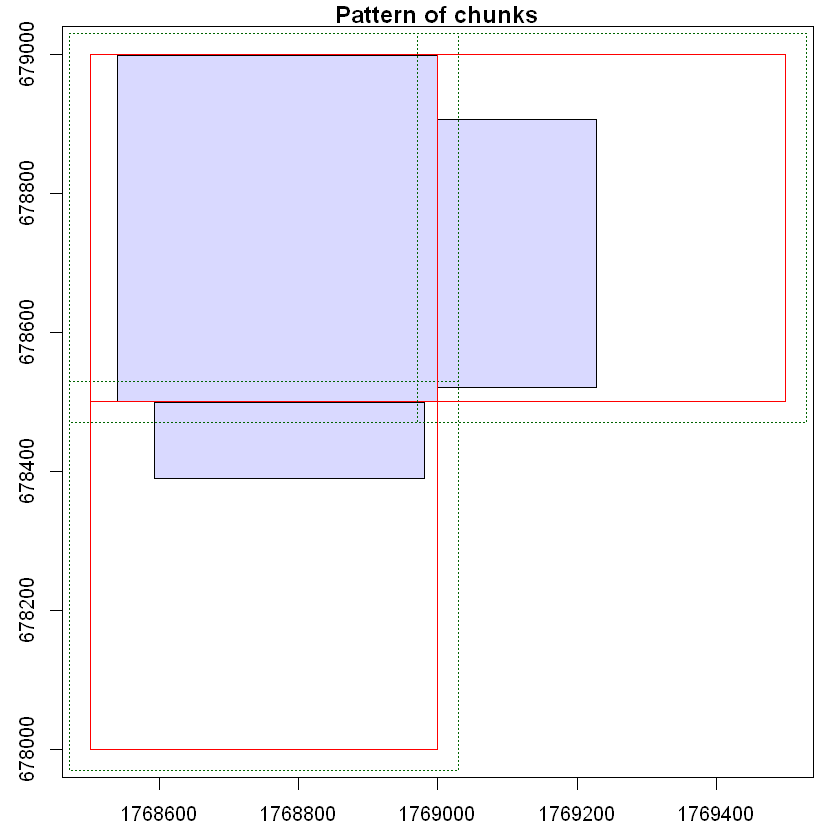

In [23]:
# Reload classified tiles as a fresh clean catalog
ctg_classified <- readLAScatalog(list.files(file.path(scratch_dir, "classified"),
                                             pattern = "\\.laz$", full.names = TRUE))

opt_chunk_size(ctg_classified)   <- 500
opt_chunk_buffer(ctg_classified) <- 30

# Return a single merged raster directly rather than writing one raster per tile
opt_output_files(ctg_classified) <- ""

# Limit to 4 workers so only 4 TIN operations run simultaneously —
# TIN is very memory intensive and running too many at once will freeze the machine
plan(multisession, workers = 4)

dtm <- rasterize_terrain(
  ctg_classified,
  res       = 0.1,      # 0.25 m pixel size for initial testing (change to 0.25 for final run)
  algorithm = tin()   # Delaunay TIN built from ground-classified points
)

# Restore full workers for subsequent steps
plan(multisession, workers = min(parallel::detectCores() - 1, 60))

writeRaster(dtm, file.path(out_dir, "bart_chunk_dtm_0.1m.tif"), overwrite = TRUE)
cat("DTM written to bart_chunk_dtm_0.1m.tif\n")

---

## ONLY RUN IF YOU NEED THE POINT CLOUD ITSELF TO BE ELEVATION AND NOT HEIGHT ABOVE SEA LEVEL - it takes forever to run otherwise 
## 4. Height-Normalize the Point Cloud

Subtracts the terrain elevation (via TIN) from every point's Z value, so that ground
points become Z ≈ 0 and all other points represent **height above
ground** rather than height above sea level.

Each normalized tile is written to scratch_dir and later read back as a catalog
for step 5 — avoids holding the entire normalized cloud in memory.

> **Note:** Same as step 3, workers are reduced to 2 to prevent memory exhaustion.

In [ ]:
# # Limit to 2 workers — TIN normalization is as memory intensive as TIN terrain generation
# plan(multisession, workers = 2)

# # Write each normalized tile to scratch_dir named by its spatial position
# opt_output_files(ctg_classified)    <- file.path(scratch_dir, "normalized/tile_{XLEFT}_{YBOTTOM}")
# opt_laz_compression(ctg_classified) <- TRUE

# # Run normalization — subtracts terrain elevation (via TIN) from every point's Z
# # lidR processes tiles in parallel and writes results to scratch_dir/normalized/
# ctg_norm <- normalize_height(ctg_classified, algorithm = tin())

# # Restore full workers for subsequent steps
# plan(multisession, workers = min(parallel::detectCores() - 1, 60))

# # Sanity check: load just the first tile (not the whole cloud) and verify
# # ground points cluster near Z = 0
# las_norm_check <- readLAS(list.files(file.path(scratch_dir, "normalized"),
#                                       pattern = "\\.laz$", full.names = TRUE)[1])
# hist(filter_ground(las_norm_check)$Z, main = "Ground point heights after normalization")

---

## 5. DSM from First Returns

The DSM represents the highest surface the lidar pulse hits — treetops,
rooftops, etc. Using only **first returns** ensures we capture the top
of the canopy rather than pulses that penetrated through gaps.

Chunk 1 of 3 (33.3%): state <U+2713>
Chunk 3 of 3 (66.7%): state <U+2713>
Chunk 2 of 3 (100%): state <U+2713>
DSM written to bart_chunk_dsm_0.1m.tif


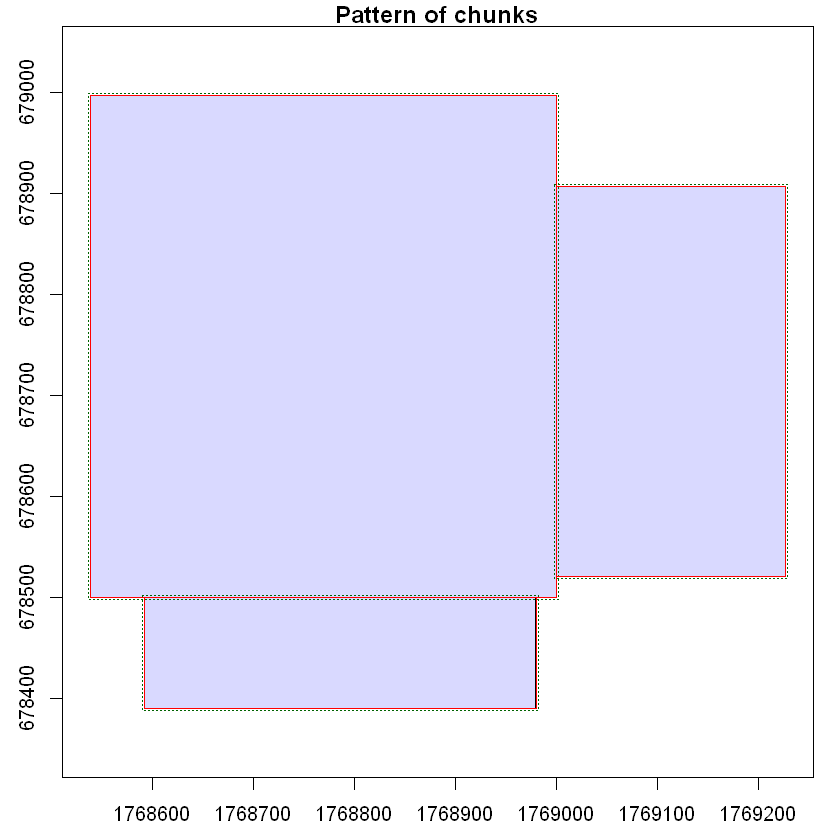

In [24]:
# Load classified tiles as a fresh catalog from scratch_dir
ctg_dsm <- readLAScatalog(list.files(file.path(scratch_dir, "classified"),
                                       pattern = "\\.laz$", full.names = TRUE))

# Filter to first returns only at the catalog level — avoids loading all returns into memory
opt_filter(ctg_dsm) <- "-keep_first"

# Return a single merged raster directly rather than one raster per tile
opt_output_files(ctg_dsm) <- ""

dsm <- rasterize_canopy(
  ctg_dsm,
  res       = 0.1,      # 0.5 m pixel size for initial testing (change to 0.25 for final run)
  algorithm = p2r(subcircle = 0.1)  # point-to-raster; subcircle fills tiny gaps
  # Smoother alternative:
  # algorithm = dsmtin()
)

writeRaster(dsm, file.path(out_dir, "bart_chunk_dsm_0.1m.tif"), overwrite = TRUE)
cat("DSM written to bart_chunk_dsm_0.1m.tif\n")

---

## 6. CHM = DSM − DTM

Subtracting the DTM from the DSM removes terrain elevation, leaving only
**canopy height above ground**.

In [25]:
# Align extents before subtracting (should already match, but just in case)
dtm_aligned <- resample(dtm, dsm, method = "bilinear")

chm <- dsm - dtm_aligned

# Clamp negative values to 0 (artefacts where DSM dips below DTM)
chm <- clamp(chm, lower = 0, values = TRUE)

writeRaster(chm, file.path(out_dir, "bart_chunk_chm_0.1m.tif"), overwrite = TRUE)
cat("CHM written to bart_chunk_chm_0.1m.tif\n")

CHM written to bart_chunk_chm_0.1m.tif


---

## 7. Clip to AOI Boundary

In [27]:
# Step 1: pop-up folder picker for the .gdb
gdb_path <- tcltk::tk_choose.files(caption = "Select your .gdb folder or .gpkg file") # change to choose.dir() if you want to select a folder instead of a file

# Step 2: list all layers and print them
layers <- st_layers(gdb_path)$name
cat("Layers found in geodatabase:\n")
for (i in seq_along(layers)) {
  cat(i, ":", layers[i], "\n")
}

# Step 3: type the number of the layer you want in the console when prompted
layer_index <- as.integer(readline(prompt = "Enter the number of the layer to use: "))
layer_name  <- layers[layer_index]
cat("Using layer:", layer_name, "\n")

# Step 4: read and reproject to match CHM
boundary <- st_read(gdb_path, layer = layer_name, quiet = TRUE)
boundary <- st_transform(boundary, crs = terra::crs(chm))

# Step 5: clip
chm_clipped <- mask(crop(chm, vect(boundary)), vect(boundary))

writeRaster(chm_clipped, file.path(out_dir, "bart_chm_0.1m_clipped.tif"), overwrite = TRUE)
cat("Clipped CHM written to bart_chm_0.1m_clipped.tif\n")

Warning message in CPL_get_layers(dsn, options, do_count):
"GDAL Message 1: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'C:\Users\kdavis99\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Bartleson_Ranch_Output_Files\bartleson_ranch_gedi.gpkg' may only be partially supported"


Layers found in geodatabase:
1 : bartleson_1_gedi_footprints_clipped 
2 : bartleson_boundary 
3 : bartleson_crops_boundaries 
4 : candidates_for_measuring_w_reduced_geoloc_err 
5 : merged_4a_4b 
6 : 4a_bartleson_boundary 
7 : 4b_bartleson_boundary 
8 : layer_styles 
Using layer: merged_4a_4b 


Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
"GDAL Message 1: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on 'C:\Users\kdavis99\OneDrive - Cal Poly\Tree Biomass Estimation Research - Documents\CODE\Bartleson_Ranch_Output_Files\bartleson_ranch_gedi.gpkg' may only be partially supported"


Clipped CHM written to bart_chm_0.1m_clipped.tif


## 7b. Extract AOI Bounding Box for GEDI Data Pull

Reprojects the boundary to WGS84 (lat/long) and prints the bounding box
coordinates you can copy directly into your Python GEDI data pull script.

In [ ]:
# # Reproject boundary to WGS84 (EPSG:4326) for lat/long coordinates
# boundary_wgs84 <- st_transform(boundary, crs = 4326)

# # Get bounding box
# bb <- st_bbox(boundary_wgs84)

# cat("── AOI Bounding Box (WGS84) ──────────────────\n")
# cat(sprintf("  Min Longitude (West)  : %.6f\n", bb["xmin"]))
# cat(sprintf("  Max Longitude (East)  : %.6f\n", bb["xmax"]))
# cat(sprintf("  Min Latitude  (South) : %.6f\n", bb["ymin"]))
# cat(sprintf("  Max Latitude  (North) : %.6f\n", bb["ymax"]))
# cat("──────────────────────────────────────────────\n")
# cat("\nPython-ready (copy-paste):\n")
# cat(sprintf("LAT_MIN, LAT_MAX = %.3f, %.3f\nLON_MIN, LON_MAX = %.3f, %.3f\n",
#             bb["ymin"], bb["ymax"], bb["xmin"], bb["xmax"]))

---

## 8. Summary Statistics

Canopy height percentiles, matching the GEDI RH metric comparisons used
in Mishra & Singh (2026): RH95 ↔ P95, RH98 ↔ P98, etc.

In [ ]:
cat("\n── CHM summary (clipped) ──\n")
print(summary(values(chm_clipped), na.rm = TRUE))

chm_vals <- values(chm_clipped, na.rm = TRUE)
cat(sprintf("P95  = %.2f m\n", quantile(chm_vals, 0.95)))
cat(sprintf("P98  = %.2f m\n", quantile(chm_vals, 0.98)))
cat(sprintf("P99  = %.2f m\n", quantile(chm_vals, 0.99)))
cat(sprintf("P100 = %.2f m\n", max(chm_vals)))

---

## 9. Plot

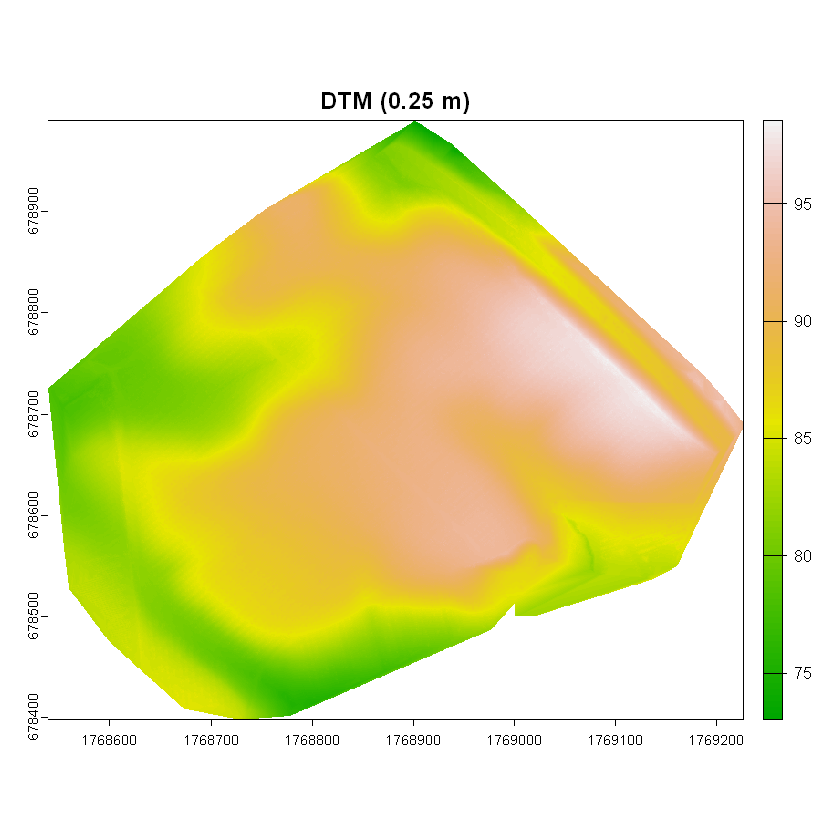

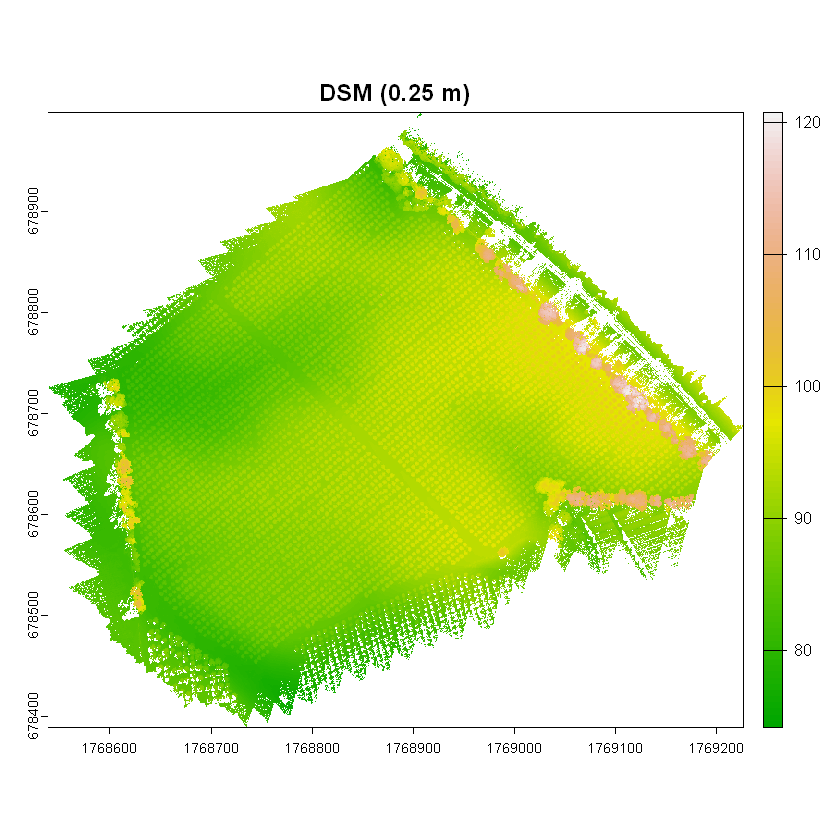

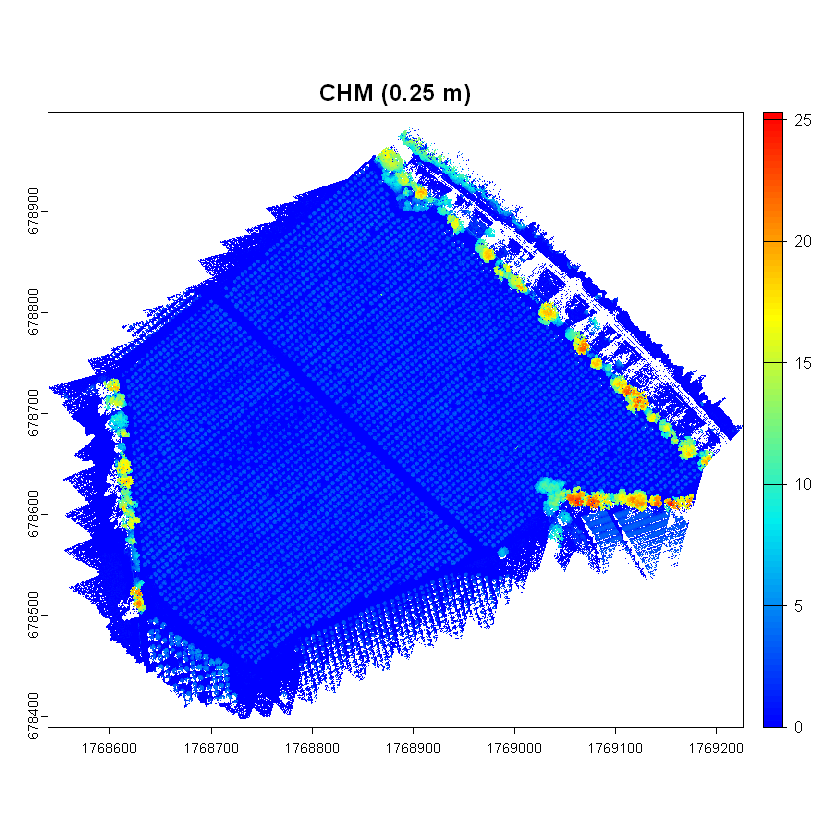

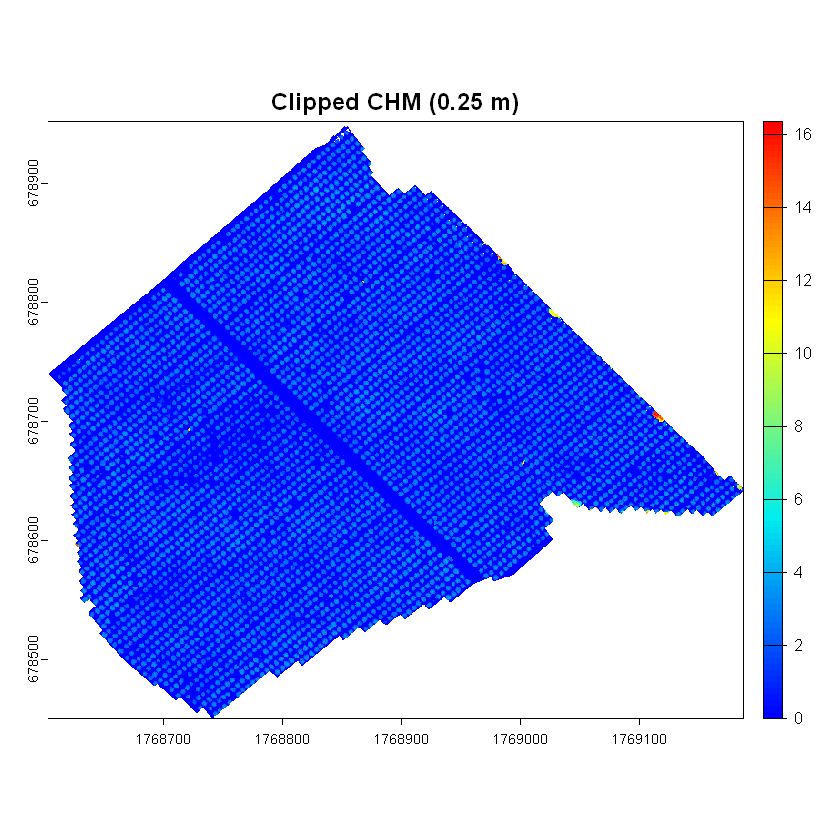

In [28]:
par(mfrow = c(1,1))
plot(dtm,         main = "DTM (0.25 m)",         col = terrain.colors(100))
plot(dsm,         main = "DSM (0.25 m)",         col = terrain.colors(100))
plot(chm, main = "CHM (0.25 m)", col = height.colors(100))
plot(chm_clipped, main = "Clipped CHM (0.25 m)", col = height.colors(100))


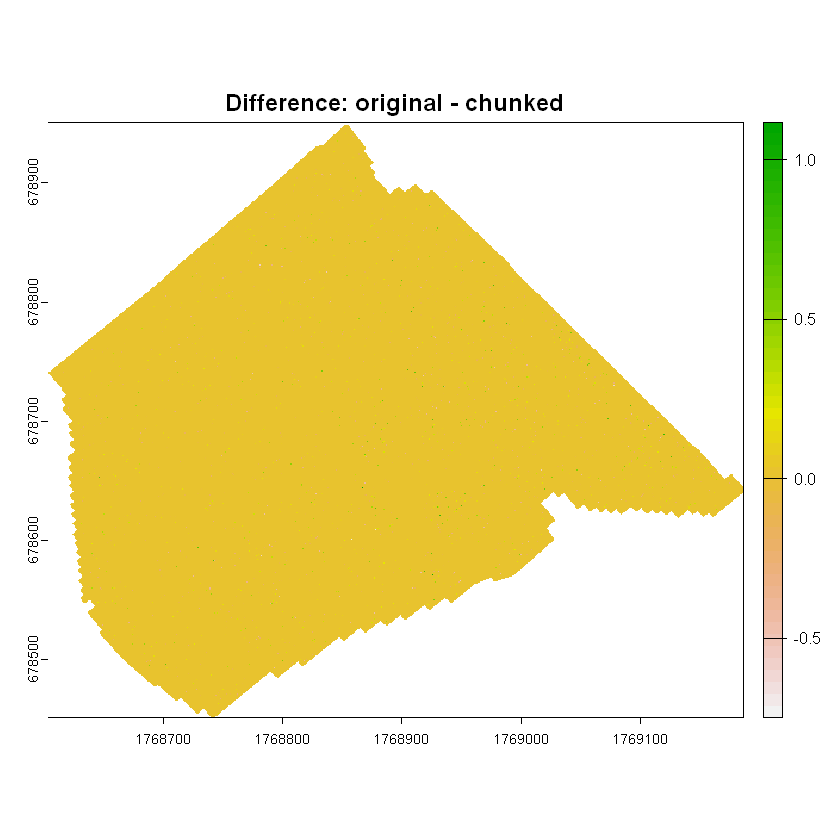

In [9]:
chm_original <- rast(file.path(out_dir, "bart_chm_1.0m.tif"))
chm_original_clipped <- mask(crop(chm_original, vect(boundary)), vect(boundary))
writeRaster(chm_original_clipped, file.path(out_dir, "bart_chm_1.0m_clipped.tif"), overwrite = TRUE)

diff <- rast(file.path(out_dir, "bart_chm_1.0m_clipped.tif")) - rast(file.path(out_dir, "bart_chunk_chm_1m_clipped.tif"))
plot(diff, main = "Difference: original - chunked")

---

## References

Zhang, W., Qi, J., Wan, P., Wang, H., Xie, D., Wang, X., & Yan, G.
(2016). An easy-to-use airborne LiDAR data filtering method based on
cloth simulation. *Remote Sensing*, 8(6), 501.
<https://doi.org/10.3390/rs8060501>

Mishra, N. B., & Singh, P. B. (2026). Mountains of error: UAV LiDAR
benchmarking of GEDI and GEDI-derived global canopy height products in
steep Himalayan forests. *International Journal of Applied Earth
Observation and Geoinformation*, 147, 105203.

Yuwen Fu, Wang Li, Wensheng Duan, Jie Bai, Li Wang & Zheng Niu
(2025) Comparison of UAV-LiDAR-driven biomass estimation approaches in planted forests
with different management, International Journal of Digital Earth, 18:2, 2576910, DOI:
10.1080/17538947.2025.2576910